# 4.4. Softmax Regression Implementation from Scratch

이번 장에서는 Fashion-MNIST 이미지 분류 모델을 직접 구현한다.

- Softmax 함수
- Weight와 bias
- Forward 계산
- Cross-Entropy Loss
- Accuracy 계산
- Training loop
- Validation
- 예측 결과 확인

## 0. 기본 설정

PyTorch를 불러오고 현재 환경을 확인

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


## 1. Fashion-MNIST 데이터 준비

Fashion-MNIST 이미지는 다음 shape을 가진다.

    [channel, height, width]
    [1, 28, 28]

흑백 이미지이므로 channel은 1이다.

Softmax regression에서는 이미지를 한 줄로 펼쳐서 사용한다.

    1 × 28 × 28 = 784

따라서 이미지 한 장은 784개의 feature를 가진 데이터가 된다.

Fashion-MNIST의 class는 10개이므로 모델은 각 이미지마다
10개의 class 점수를 출력해야 한다.

    입력 feature 수 = 784
    출력 class 수 = 10

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("훈련 데이터 개수:", len(train_dataset))
print("테스트 데이터 개수:", len(test_dataset))

훈련 데이터 개수: 60000
테스트 데이터 개수: 10000


In [5]:
X, y = next(iter(train_loader))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([256, 1, 28, 28])
y shape: torch.Size([256])


현재 minibatch의 shape은 다음과 같다.

    X.shape = [256, 1, 28, 28]
    y.shape = [256]

각 숫자의 의미는 이렇다

    [batch_size, channel, height, width]

X에는 256장의 흑백 이미지가 들어 있다.

각 이미지의 정답 class 번호는 y에 들어 있다.

In [6]:
X_flat = X.reshape(X.shape[0], -1)

print("펼치기 전:", X.shape)
print("펼친 후:", X_flat.shape)

펼치기 전: torch.Size([256, 1, 28, 28])
펼친 후: torch.Size([256, 784])


`reshape(X.shape[0], -1)`을 사용하면 각 이미지를 한 줄로 펼칠 수 있다.

    [256, 1, 28, 28]
            ↓
    [256, 784]

- 256: minibatch에 들어 있는 이미지 개수
- 784: 이미지 한 장의 전체 픽셀 수

`-1`은 나머지 차원의 크기를 PyTorch가 자동으로 계산하라는 뜻이다.

## 2. Tensor의 차원별 합

Softmax를 구현하려면 각 데이터의 class 점수를 모두 더해야 한다.

예를 들어 다음 Tensor가 있다고 하자.

    X = [
        [1, 2, 3],
        [4, 5, 6]
    ]

shape은 다음과 같다.

    [2, 3]

- 행은 데이터 2개를 의미한다.
- 열은 각 데이터의 값 3개를 의미한다.

In [ ]:
X_example = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])

print("dim=0 합:") # 세로 방향으로 더하기 
print(X_example.sum(dim=0, keepdim=True))

print("\ndim=1 합:") # 가로 방향으로 더하기 (Softmax에선 가로방향)
print(X_example.sum(dim=1, keepdim=True))

dim=0 합:
tensor([[5., 7., 9.]])

dim=1 합:
tensor([[ 6.],
        [15.]])


In [8]:
sum_without_keepdim = X_example.sum(dim=1)
sum_with_keepdim = X_example.sum(dim=1, keepdim=True)

print("keepdim=False:", sum_without_keepdim)
print("shape:", sum_without_keepdim.shape)

print()

print("keepdim=True:")
print(sum_with_keepdim)
print("shape:", sum_with_keepdim.shape)

keepdim=False: tensor([ 6., 15.])
shape: torch.Size([2])

keepdim=True:
tensor([[ 6.],
        [15.]])
shape: torch.Size([2, 1])


`keepdim=False`이면 결과 shape은 이럴것 이다.

    [2]

`keepdim=True`이면 합한 차원을 크기 1로 유지한다.

    [2, 1]

Softmax에서는 원래 Tensor의 각 행을 행의 합으로 나눠야 한다.

    [2, 3] / [2, 1]

이때 broadcasting을 사용하기 위해 `[2, 1]` 형태를 유지하는 것이 편하다.

## 3. Softmax

모델이 출력한 원래 점수를 logits라고 한다.

예를 들어서 다음과 같은 logits가 있다고 하자.

    [2.0, 1.0, 0.1]

이 값들은 아직 확률이 아니다.

- 음수가 나올 수 있다.
- 합이 1이 아니다.
- 확률로 직접 해석하기 어렵다.

Softmax는 logits를 class별 확률처럼 해석할 수 있는 값으로 바꾼다.

$$
\text{softmax}(X)_{ij}
=
\frac{\exp(X_{ij})}
{\sum_k \exp(X_{ik})}
$$

계산 순서는 다음과 같다.

1. 각 값에 exponential을 적용한다.
2. 각 행의 값을 모두 더한다.
3. 각 값을 해당 행의 합으로 나눈다.

In [9]:
def softmax_basic(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(dim=1, keepdim=True)

    return X_exp / partition

logits_example = torch.tensor([
    [2.0, 1.0, 0.1],
    [0.5, 2.5, 1.0]
])

probabilities = softmax_basic(logits_example)

print("logits:")
print(logits_example)

print("\nsoftmax 결과:")
print(probabilities)

print("\n각 행의 합:")
print(probabilities.sum(dim=1))

logits:
tensor([[2.0000, 1.0000, 0.1000],
        [0.5000, 2.5000, 1.0000]])

softmax 결과:
tensor([[0.6590, 0.2424, 0.0986],
        [0.0996, 0.7361, 0.1643]])

각 행의 합:
tensor([1.0000, 1.0000])


Softmax 결과는 다음 성질을 가진다.

- 모든 값이 0 이상이다.
- 각 값은 0과 1 사이이다.
- 각 행의 합은 1이다.

각 행은 데이터 하나에 대한 class별 확률 분포처럼 해석할 수 있다.

예를 들어서
    [0.6590, 0.2424, 0.0986]

이라면 모델은 첫 번째 class가 가장 가능성이 높다고 판단한 것이다.

가장 높은 값을 가진 class는 `argmax`로 구한다.

In [10]:
predictions = probabilities.argmax(dim=1)

print("예측 class:", predictions)

예측 class: tensor([0, 1])


D2L에서는 단순한 exp(X) 구현은 값이 너무 크거나 작을 때 수치적으로 불안정하기 때문에 실제 용도에 그대로 사용하면 안된다고 경고한다.

### 안정적인 Softmax

단순한 softmax 구현에는 문제가 있다.

`torch.exp()`에 매우 큰 값이 들어가면 무한대가 발생할 수 있다.

예를 들어서
    exp(1000)

은 컴퓨터가 표현할 수 있는 범위를 넘어갈 수 있다.

이 문제를 줄이기 위해 각 행에서 가장 큰 값을 먼저 뺀다.

    X_stable = X - X.max(...)

같은 값을 모든 class 점수에서 빼더라도
가장 큰 값의 위치와 최종 softmax 확률은 변하지 않는다.

직접 구현할 때는 안정적인 버전을 사용하는 것이 낫다고 한다.

In [13]:
def softmax(X):
    X_stable = X - X.max(dim=1, keepdim=True).values
    X_exp = torch.exp(X_stable)
    partition = X_exp.sum(dim=1, keepdim=True)

    return X_exp / partition

large_logits = torch.tensor([
    [1000.0, 1001.0, 1002.0]
])

print(softmax(large_logits))
print("합:", softmax(large_logits).sum(dim=1))

tensor([[0.0900, 0.2447, 0.6652]])
합: tensor([1.])


[1000, 1001, 1002] 에서 1002를 빼면 [-2, -1, 0]가 된다.

상대적인 차이는 그대로지만 exponential계산에서 overflow가 발생할 가능성이 줄어든다.

실제 프로젝트에서는 직접 만든 softmax보다 PyTorch가 제공하는 안정적인 구현을 사용하는 것이 맞다고 한다.

## 4. Softmax Regression 모델

Softmax regression의 선형 계산은 다음과 같다.

$$
O = XW + b
$$

각 Tensor의 shape은 다음과 같다.

    X: [batch_size, 784]
    W: [784, 10]
    b: [10]

행렬곱 결과는 다음과 같다.

    [batch_size, 784] @ [784, 10]
    → [batch_size, 10]

bias가 더해져도 shape은 그대로다.

    O.shape = [batch_size, 10]

`O`에는 각 이미지에 대한 10개 class 점수가 들어 있다.
이 점수를 logits라고 한다.

In [14]:
num_inputs = 28 * 28
num_outputs = 10

W = torch.normal(
    mean=0.0,
    std=0.01,
    size=(num_inputs, num_outputs),
    requires_grad=True
)

b = torch.zeros(
    num_outputs,
    requires_grad=True
)

print("W shape:", W.shape)
print("b shape:", b.shape)

W shape: torch.Size([784, 10])
b shape: torch.Size([10])


Weight `W`는 작은 무작위 값으로 초기화한다.

    W.shape = [784, 10]

784개의 입력 feature 각각이 10개 class 점수에 영향을 준다.

Bias `b`는 0으로 초기화한다.

    b.shape = [10]

각 class마다 하나의 bias가 필요하므로 원소가 10개이다.

`requires_grad=True`를 설정했기 때문에 `loss.backward()`를 실행하면 W와 b의 gradient가 계산된다.

## 5. Forward 계산

1. 이미지 Tensor를 784개 feature로 펼친다.
2. `X @ W + b`로 class 점수를 계산한다.
3. Softmax를 적용해 class별 확률을 계산한다.

In [ ]:
def forward(X):
    X = X.reshape(X.shape[0], -1)

    logits = X @ W + b
    probabilities = softmax(logits)

    return probabilities

X_batch, y_batch = next(iter(train_loader))

y_hat = forward(X_batch)

print("입력 X shape:", X_batch.shape)
print("출력 y_hat shape:", y_hat.shape) # 이미지가 256개 있고 10개마다 class예측확률 있음.
print("첫 번째 데이터의 확률 합:", y_hat[0].sum())

입력 X shape: torch.Size([256, 1, 28, 28])
출력 y_hat shape: torch.Size([256, 10])
첫 번째 데이터의 확률 합: tensor(1.0000, grad_fn=<SumBackward0>)


In [16]:
print("첫 번째 이미지의 예측 확률:")
print(y_hat[0])

print("\n첫 번째 이미지의 예측 class:")
print(y_hat[0].argmax())

print("\n첫 번째 이미지의 실제 정답:")
print(y_batch[0])

첫 번째 이미지의 예측 확률:
tensor([0.0911, 0.1003, 0.1074, 0.0969, 0.1148, 0.0996, 0.0968, 0.0949, 0.1017,
        0.0964], grad_fn=<SelectBackward0>)

첫 번째 이미지의 예측 class:
tensor(4)

첫 번째 이미지의 실제 정답:
tensor(7)


## 6. Cross-Entropy Loss

분류 모델은 정답 class에 높은 확률을 주도록 학습해야 한다.

예를 들어 정답이 class 2라면 다음 출력 중 두 번째가 더 좋은 예측이다.

    예측 A = [0.3, 0.3, 0.4]
    예측 B = [0.01, 0.01, 0.98]

두 예측 모두 argmax는 class 2이므로 accuracy에서는 둘 다 정답이다.

근데 예측 B가 정답 class에 더 높은 확률을 주었다.

Cross-entropy는 정답 class에 부여한 확률을 이용해
두 예측의 차이를 구분한다.

데이터 하나에 대한 loss는 다음과 같다.

$$
L = -\log(\hat{y}_y)
$$

여기서:

- $\hat{y}$는 모델이 출력한 확률이다.
- $y$는 실제 정답 class 번호이다.
- $\hat{y}_y$는 정답 class에 대한 예측 확률이다.

In [ ]:
y_example = torch.tensor([0, 2]) # 정답은 0, 2

y_hat_example = torch.tensor([
    [0.1, 0.3, 0.6],
    [0.3, 0.2, 0.5]
])

print("예측 확률:")  # 정답이 0,2라서 선택해야하는건 0.1, 0.5이다.
print(y_hat_example)

print("\n정답:")
print(y_example)

예측 확률:
tensor([[0.1000, 0.3000, 0.6000],
        [0.3000, 0.2000, 0.5000]])

정답:
tensor([0, 2])


In [18]:
row_indices = torch.arange(len(y_hat_example))

correct_class_probabilities = y_hat_example[
    row_indices,
    y_example
]

print(correct_class_probabilities)

tensor([0.1000, 0.5000])


다음 indexing의 의미는 각 행에서 정답 class 위치를 선택하는 것이다.

    y_hat[row_indices, y]

현재 값은 다음과 같다.

    row_indices = [0, 1]
    y           = [0, 2]

따라서 선택되는 위치는 다음과 같다.

    y_hat[0, 0]
    y_hat[1, 2]

Python 반복문을 사용하지 않고 minibatch 전체의 정답 확률을
한 번에 가져올 수 있다.

In [19]:
def cross_entropy(y_hat, y):
    row_indices = torch.arange(
        len(y_hat),
        device=y_hat.device
    )

    correct_probabilities = y_hat[row_indices, y]

    return -torch.log(correct_probabilities + 1e-12).mean()

loss_example = cross_entropy(
    y_hat_example,
    y_example
)

print("cross-entropy loss:", loss_example)

cross-entropy loss: tensor(1.4979)


Cross-entropy 계산 과정은 다음과 같다.

정답 class 확률:

    [0.1, 0.5]

음의 로그 적용:

    [-log(0.1), -log(0.5)]

평균:

    (-log(0.1) - log(0.5)) / 2

정답 class 확률이 1에 가까울수록 loss는 작아진다.

정답 class 확률이 0에 가까울수록 loss는 크게 증가한다.

`1e-12`를 더한 이유는 확률이 정확히 0일 때
`log(0)`이 발생하는 것을 피하기 위해서다.

In [ ]:
probabilities_example = torch.tensor([
    0.99,
    0.90,
    0.50,
    0.10,
    0.01
])

losses_example = -torch.log(probabilities_example)

for probability, loss_value in zip(
    probabilities_example,
    losses_example
):
    print(
        f"정답 확률: {probability.item():.2f}, " # 확률이 높아질수록 loss는 낮아짐
        f"loss: {loss_value.item():.4f}"
    ) # 모델은 정답 class에 높은 확률을 주도록 학습함.

정답 확률: 0.99, loss: 0.0101
정답 확률: 0.90, loss: 0.1054
정답 확률: 0.50, loss: 0.6931
정답 확률: 0.10, loss: 2.3026
정답 확률: 0.01, loss: 4.6052


## 7. Accuracy

Accuracy는 전체 데이터 중 모델이 정답을 맞힌 비율이다.

$$
\text{accuracy}
=
\frac{\text{맞힌 개수}}
{\text{전체 데이터 개수}}
$$

모델 출력에서 가장 높은 확률을 가진 class를 예측값으로 사용한다.

    y_pred = y_hat.argmax(dim=1)

In [21]:
def accuracy(y_hat, y):
    y_pred = y_hat.argmax(dim=1)

    return (y_pred == y).float().mean()

print(
    "예시 accuracy:",
    accuracy(y_hat_example, y_example).item()
)

예시 accuracy: 0.5


## 8. SGD 업데이트

`loss.backward()`를 실행하면 W와 b의 gradient가 계산된다.

SGD는 다음 식으로 파라미터를 업데이트한다.

$$
W \leftarrow W - \eta \frac{\partial L}{\partial W}
$$

$$
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

여기서 $\eta$는 learning rate이다.

업데이트가 끝난 뒤에는 gradient를 0으로 초기화해야 한다.

PyTorch는 gradient를 자동으로 덮어쓰지 않고 누적하기 때문이다.

In [27]:
def sgd(params, learning_rate):
    with torch.no_grad(): # 파라미터 업데이트를 새로운 계산 그래프에 기록할 필요가 없기 때문
        for param in params:
            param -= learning_rate * param.grad # 파라미터 변경
            param.grad.zero_() # grad 초기화

## 9. Validation 함수

Validation에서는 파라미터를 업데이트하지 않는다.

따라서 다음 작업을 하지 않는다.

- `loss.backward()`
- SGD 업데이트
- gradient 계산

`@torch.no_grad()`를 사용하면 validation 중에
계산 그래프와 gradient를 저장하지 않는다.

전체 loss는 batch별 평균을 다시 단순 평균하지 않는다.

마지막 batch의 크기가 다를 수 있으므로 다음처럼 계산한다.

    batch loss × batch 데이터 수

를 모두 더한 뒤 전체 데이터 수로 나눈다.

Accuracy은 다음처럼 계산한다.

    전체 맞힌 개수 / 전체 데이터 개수

In [22]:
@torch.no_grad()
def evaluate(model_forward, data_loader, device):
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X, y in data_loader:
        X = X.to(device)
        y = y.to(device)

        y_hat = model_forward(X)
        loss = cross_entropy(y_hat, y)

        batch_size = y.shape[0]

        total_loss += loss.item() * batch_size
        total_correct += (
            y_hat.argmax(dim=1) == y
        ).sum().item()
        total_samples += batch_size

    average_loss = total_loss / total_samples
    average_accuracy = total_correct / total_samples

    return average_loss, average_accuracy

## 10. Training

하나의 minibatch에 대한 학습 순서는 다음과 같다.

1. 이미지를 모델에 입력한다.
2. 예측 확률을 계산한다.
3. Cross-entropy loss를 계산한다.
4. `backward()`로 gradient를 계산한다.
5. SGD로 W와 b를 업데이트한다.

이 과정을 모든 minibatch에 대해 반복하면 1 epoch이다.

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)

device: cpu


In [24]:
W = torch.normal(
    mean=0.0,
    std=0.01,
    size=(num_inputs, num_outputs),
    device=device,
    requires_grad=True
)

b = torch.zeros(
    num_outputs,
    device=device,
    requires_grad=True
)

print("W device:", W.device)
print("b device:", b.device)

W device: cpu
b device: cpu


In [ ]:
learning_rate = 0.1
num_epochs = 10

train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(num_epochs):
    total_train_loss = 0.0
    total_train_correct = 0
    total_train_samples = 0

    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)

        y_hat = forward(X)
        loss = cross_entropy(y_hat, y)

        loss.backward()
        sgd([W, b], learning_rate)

        batch_size = y.shape[0]

        total_train_loss += loss.item() * batch_size
        total_train_correct += (
            y_hat.argmax(dim=1) == y
        ).sum().item()
        total_train_samples += batch_size

    train_loss = (
        total_train_loss / total_train_samples
    )

    train_acc = (
        total_train_correct / total_train_samples
    )

    test_loss, test_acc = evaluate(
        forward,
        test_loader,
        device
    )

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(
        f"Epoch {epoch + 1:2d} | "
        f"train loss: {train_loss:.4f} | " # 평균 cross-entropy loss
        f"train acc: {train_acc:.4f} | " # 정답 맞힌 비율
        f"test loss: {test_loss:.4f} | " # 학습에 사용하지 않은 데이터에서 계산한 loss
        f"test acc: {test_acc:.4f}" # 학습에 사용하지 않은 데이터에서  정답 맞힌 비율
    )

Epoch  1 | train loss: 0.7725 | train acc: 0.7535 | test loss: 0.6491 | test acc: 0.7737
Epoch  2 | train loss: 0.5701 | train acc: 0.8132 | test loss: 0.5718 | test acc: 0.8059
Epoch  3 | train loss: 0.5252 | train acc: 0.8252 | test loss: 0.5554 | test acc: 0.8056
Epoch  4 | train loss: 0.5013 | train acc: 0.8324 | test loss: 0.5293 | test acc: 0.8176
Epoch  5 | train loss: 0.4852 | train acc: 0.8376 | test loss: 0.5296 | test acc: 0.8158
Epoch  6 | train loss: 0.4739 | train acc: 0.8402 | test loss: 0.5129 | test acc: 0.8223
Epoch  7 | train loss: 0.4652 | train acc: 0.8433 | test loss: 0.5049 | test acc: 0.8188
Epoch  8 | train loss: 0.4574 | train acc: 0.8459 | test loss: 0.4880 | test acc: 0.8305
Epoch  9 | train loss: 0.4520 | train acc: 0.8463 | test loss: 0.4972 | test acc: 0.8270
Epoch 10 | train loss: 0.4480 | train acc: 0.8480 | test loss: 0.4833 | test acc: 0.8324


## 11. 학습 곡선

Epoch에 따른 train/test loss와 accuracy를 그려 학습이 안정적으로 진행되는지 확인한다.


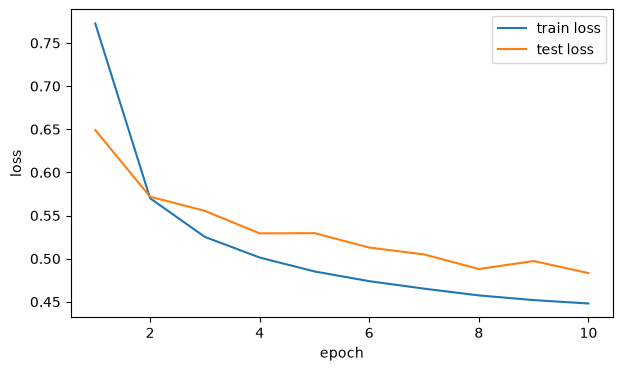

In [29]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    train_loss_history,
    label="train loss"
)

plt.plot(
    epochs,
    test_loss_history,
    label="test loss"
)

plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

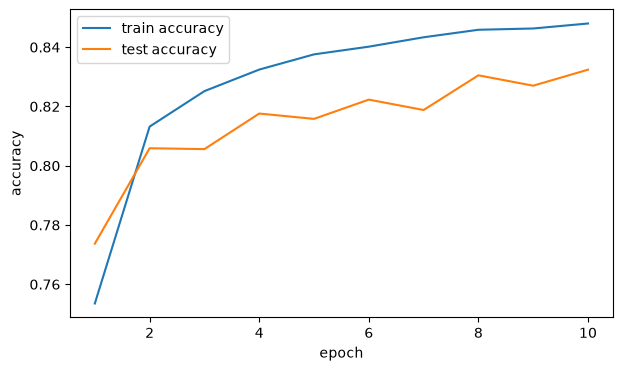

In [30]:
plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    train_acc_history,
    label="train accuracy"
)

plt.plot(
    epochs,
    test_acc_history,
    label="test accuracy"
)

plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

## 12. 예측 결과 확인

D2L에서도 학습 끝나고 validation minibatch를 가져와서 argmax로 예측 class를 구한다.

In [31]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

X_test, y_test = next(iter(test_loader))

X_test_device = X_test.to(device)

with torch.no_grad():
    y_hat_test = forward(X_test_device)
    predictions = y_hat_test.argmax(dim=1).cpu()

print("predictions shape:", predictions.shape)
print("앞쪽 예측:", predictions[:10])
print("앞쪽 정답:", y_test[:10])

predictions shape: torch.Size([256])
앞쪽 예측: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])
앞쪽 정답: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])


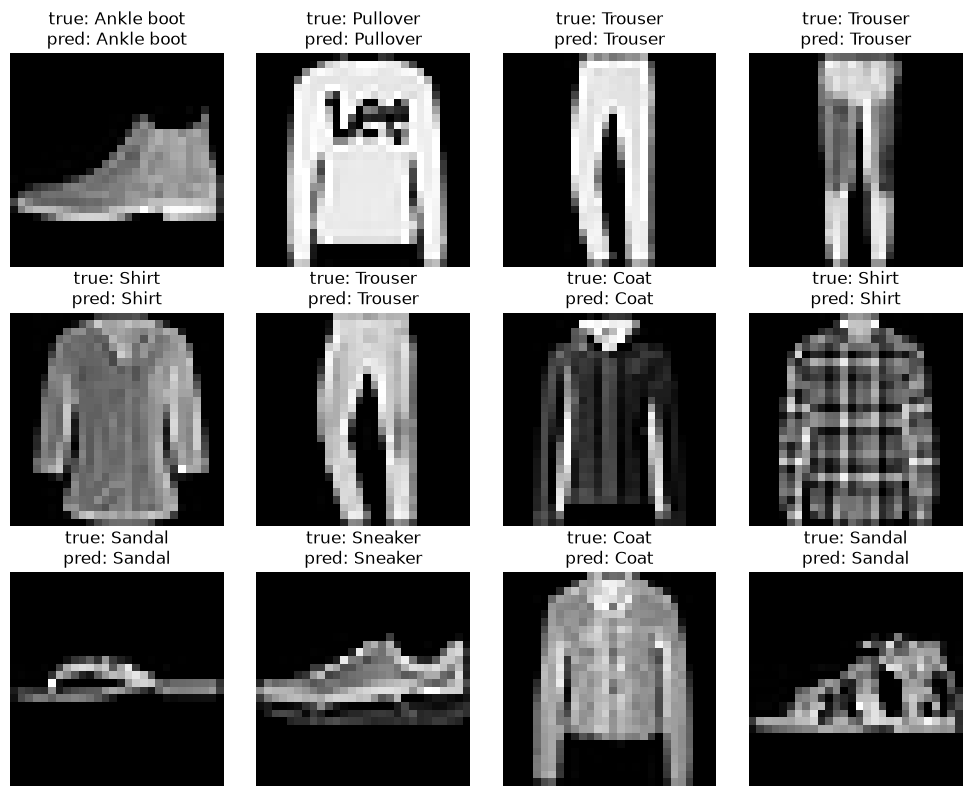

In [ ]:
num_images = 12

fig, axes = plt.subplots(
    3,
    4,
    figsize=(10, 8)
)

axes = axes.flatten()

for i in range(num_images):
    true_label = class_names[y_test[i].item()]
    predicted_label = class_names[predictions[i].item()]

    axes[i].imshow(
        X_test[i].squeeze(0),
        cmap="gray"
    )

    axes[i].set_title(
        f"true: {true_label}\npred: {predicted_label}" # 실제 정답, 모델 예측
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

Softmax regression은 이미지를 784개 픽셀로 펼친 뒤 처리한다.

따라서 이미지에서 가까이 있는 픽셀들의 공간적 관계를 명시적으로 활용하지 못한다.

CNN은 이미지의 가로/세로 구조를 유지하며 주변 픽셀의 패턴을 학습한다.

## 13. 모델 학습 흐름

### 1. 데이터 가져오기

    X.shape = [256, 1, 28, 28]
    y.shape = [256]

### 2. 이미지 펼치기

    X.reshape(256, 784)

### 3. 선형 계산

    logits = X @ W + b

shape:

    [256, 784] @ [784, 10] + [10]
    → [256, 10]

### 4. Softmax

    y_hat = softmax(logits)

각 이미지에 대해 10개 class의 확률을 만든다.

    y_hat.shape = [256, 10]

### 5. 정답 확률 선택

    y_hat[행 번호, 정답 class]

각 이미지에서 정답 class에 해당하는 확률만 선택한다.

### 6. Cross-Entropy Loss

    loss = -log(정답 class 확률)의 평균

### 7. Backward

    loss.backward()

W와 b의 gradient를 계산한다.

### 8. SGD

    W = W - learning_rate × W.grad
    b = b - learning_rate × b.grad

### 9. Gradient 초기화

    W.grad.zero_()
    b.grad.zero_()

## 14. 직접 구현 코드의 한계

이번 코드는 softmax regression의 내부 동작을 이해하기 위한 구현이다.

실제 프로젝트에서는 보통 다음처럼 사용한다.

- 모델: `nn.Linear`
- Loss: `nn.CrossEntropyLoss`
- Optimizer: `torch.optim.SGD`

특히 `nn.CrossEntropyLoss`는 내부에서
log-softmax와 cross-entropy를 수치적으로 안정적으로 계산한다.

따라서 `nn.CrossEntropyLoss`를 사용할 때는
모델 forward에서 softmax를 직접 적용하지 않는다.

잘못된 형태:

    probabilities = softmax(logits)
    loss = nn.CrossEntropyLoss()(probabilities, y)

올바른 형태:

    logits = model(X)
    loss = nn.CrossEntropyLoss()(logits, y)

이번 장에서는 원리를 이해하기 위해
softmax와 cross-entropy를 직접 구현한 것이다.

## 15. 오늘의 정리

- Fashion-MNIST 이미지는 `[1, 28, 28]` shape을 가진다.
- 이미지를 펼치면 784개의 feature가 된다.
- Fashion-MNIST의 class는 10개이다.
- Weight `W`의 shape은 `[784, 10]`이다.
- Bias `b`의 shape은 `[10]`이다.
- `X @ W + b`의 결과를 logits라고 한다.
- Logits의 shape은 `[batch_size, 10]`이다.
- Softmax는 logits를 class별 확률로 변환한다.
- Softmax 결과에서 각 행의 합은 1이다.
- 안정적인 softmax를 위해 각 행의 최댓값을 먼저 뺄 수 있다.
- Cross-entropy는 정답 class에 부여한 확률을 이용한다.
- 정답 class의 확률이 높을수록 loss는 작아진다.
- `loss.backward()`는 W와 b의 gradient를 계산한다.
- SGD는 gradient의 반대 방향으로 W와 b를 업데이트한다.
- 파라미터 업데이트 후에는 gradient를 0으로 초기화해야 한다.
- Accuracy는 `argmax`로 구한 예측 class와 정답을 비교한다.
- 직접 구현은 원리 학습용이다.
- 실제 구현에서는 보통 `nn.Linear`와 `nn.CrossEntropyLoss`를 사용한다.